# 🚗 İkinci El Araç Fiyat Tahmin Sistemi
## Kalibrasyon Notebook'u — Tam Dokümantasyon

**Proje:** arabam.com'dan scrape edilen 2026 verisiyle temporal covariate shift düzeltmesi  
**Model:** RF + GB Ensemble (2025 verisiyle eğitilmiş)  
**Yöntem:** Marka × Dönem hiyerarşik kalibrasyon  

---

### İçindekiler
1. [Neden Kalibrasyon Gerekli?](#1)
2. [MAE, MAPE, Bias — Ne Anlama Gelir?](#2)
3. [Veri Yükleme ve Model Eğitimi](#3)
4. [Ham Model Performansı ve Bias Teşhisi](#4)
5. [Kalibrasyon Tablosu Hesaplama](#5)
6. [4 Senaryo: Global / Dönem / Marka / Hiyerarşik](#6)
7. [Sonuçların Görselleştirilmesi](#7)
8. [Test Veri Setinde Doğrulama (959 araç)](#8)
9. [Özet ve Üretim Kodu](#9)

> **Veri dosyaları:** `verisetiTemiz2.xlsx` (eğitim, 48.258 araç, 2025),  
> `1781045195886_yeni_arabalar_temiz.xlsx` (kalibrasyon, 1.084 araç, Şubat+Mayıs 2026),  
> `yeni_arabalar_mayıshaziran.xlsx` (validasyon, 980 araç, Mayıs+Haziran 2026),  
> `veriseti_guncel_temiz.xlsx` (test, 959 araç, Şubat 2026)


---
## 1. Neden Kalibrasyon Gerekli? <a id="1"></a>

### Sorun: Temporal Covariate Shift

Makine öğrenimi modelleri **eğitildikleri dönemin fiyat dağılımını öğrenir**.  
Modelimiz 2025 yılının Ağustos ayı ağırlıklı verisiyle eğitildi.  
Fakat 2026'da arabam.com'a yeni ilanlar geldiğinde fiyatlar **ortalama %12–15 artmış** durumda.

```
Eğitim dönemi (2025):  Medyan fiyat ≈ 630.000 TL
Test dönemi   (2026):  Medyan fiyat ≈ 910.000 TL
                       ─────────────────────────
                       Artış: +%44
```

Model bunu bilmediği için sistematik olarak **düşük fiyat tahmin eder**.  
Bu hatanın adı: **Temporal Covariate Shift** (zaman kaynaklı dağılım kayması).

### Çözüm: Kalibrasyon Çarpanı

> **Çarpan = Gerçek Fiyat / Model Tahmini**  
> Eğer model 500.000 TL dedi, araç 580.000 TL'ye satıldıysa → çarpan = 1.16  
> Bu çarpanı yeterli sayıda araçta hesaplayıp medyanını alırsak  
> geleceğe dönük tahminleri düzeltmek için kullanabiliriz.

### Neden Retraining Yerine Kalibrasyon?

| Kriter | Retraining | Kalibrasyon |
|--------|-----------|-------------|
| Maliyet | Yüksek (saatler) | Sıfır |
| Veri gereksinimi | 10.000+ araç | 300+ araç |
| Uygulama süresi | Pipeline yeniden | Bir satır |
| Esneklik | Bir kez | Aylık güncellenebilir |

**Karar: Kalibrasyon, mevcut ortamda en pratik çözüm.**


---
## 2. MAE, MAPE, Bias — Ne Anlama Gelir? <a id="2"></a>

### MAE (Mean Absolute Error — Ortalama Mutlak Hata)

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

- **Ne ölçer:** Tahminlerin gerçekten ortalama kaç TL saptığını  
- **Yorumu:** MAE = 90.000 TL → Model ortalamada 90K TL yanılıyor  
- **Birimi:** TL (anlaşılması kolay)  
- **Zayıflığı:** Büyük hataları küçük hatalarla aynı ağırlıkta sayar

### MAPE (Mean Absolute Percentage Error — Ortalama Mutlak Yüzde Hata)

$$\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100$$

- **Ne ölçer:** Hatanın gerçek fiyata oranını (%)  
- **Yorumu:** MAPE = %10 → Model ortalamada %10 yanılıyor  
- **Avantajı:** Fiyat büyüklüğünden bağımsız karşılaştırma sağlar  
- **Zayıflığı:** Ucuz araçlarda (0-300K) aşırı büyüyebilir

### Bias (Sistematik Sapma)

$$\text{Bias} = \text{Medyan}\left(\frac{y_i - \hat{y}_i}{\hat{y}_i}\right) \times 100$$

- **Ne ölçer:** Modelin sistematik olarak hangi yöne saptığını  
- **Yorumu:** Bias = +12% → Model ortalamada %12 ucuz buluyor (düşük tahmin)  
- **Yorumu:** Bias = −5% → Model ortalamada %5 pahalı buluyor (yüksek tahmin)  
- **İdeal:** Bias ≈ 0 (ne hep düşük ne hep yüksek)  
- **Neden medyan?** Fiyat uçları (outlier araçlar) ortalamayı çarpar, medyan dirençlidir

### R² (Açıklama Katsayısı)

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

- **R² = 1.0** → Mükemmel tahmin  
- **R² = 0.90** → Fiyat varyasyonunun %90'ı model tarafından açıklanıyor  
- **R² = 0.0** → Model ortalama tahmininden daha iyi değil

### Düşük / Yüksek Tahmin Oranı

$$\text{Düşük Tahmin Oranı} = \frac{|\{i : \hat{y}_i < y_i\}|}{n} \times 100$$

- **Kalibrasyonsuz:** %85+ araç düşük tahmin edilir (sistematik)  
- **Kalibrasyonlu:** İdeal ~%50 (rastgele hata, yanlılık yok)


---
## 3. Veri Yükleme ve Model Eğitimi <a id="3"></a>


In [5]:

# ─── Kütüphaneler ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import category_encoders as ce
import json, warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

print("✅ Kütüphaneler yüklendi")


✅ Kütüphaneler yüklendi


Eğitim    : 48,258 araç | [2025] yılı
Kalibrasyon:   980 araç | Şub 2026 | Medyan: 910,000 TL
Validasyon :   959 araç | May+Haz 2026 | Medyan: 910,000 TL
Test       :   126 araç | Şubat 2026  | Medyan: 877,000 TL


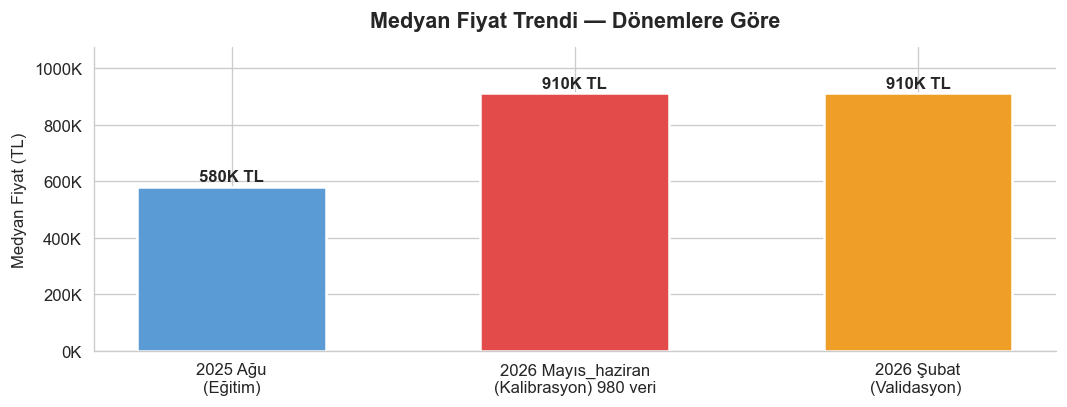


→ Fiyat artışı (Ağu 2025 → Haz 2026): %56.9


In [6]:

# ─── Veri Yükleme ─────────────────────────────────────────────────────────────
df_train = pd.read_excel('verisetiTemiz.xlsx')                                         # EĞİTİM
df_cal   = pd.read_excel('yeni_arabalar_mayıshaziran.xlsx')                             # KALİBRASYON
df_val   = pd.read_excel('yeni_araba_şubat.xlsx')                                  # VALİDASYON
df_test  = pd.read_excel('yeni_araba_126_adet.xlsx')                            # TEST

print(f"Eğitim    : {len(df_train):>6,} araç | {df_train['ilan_yil'].unique()} yılı")
print(f"Kalibrasyon: {len(df_cal):>5,} araç | Şub 2026 | Medyan: {df_cal['fiyat'].median():,.0f} TL")
print(f"Validasyon : {len(df_val):>5,} araç | May+Haz 2026 | Medyan: {df_val['fiyat'].median():,.0f} TL")
print(f"Test       : {len(df_test):>5,} araç | Şubat 2026  | Medyan: {df_test['fiyat'].median():,.0f} TL")

# Fiyat artışını görselleştir
fig, ax = plt.subplots(figsize=(9, 3.5))
donemler = {
    '2025 Ağu\n(Eğitim)': df_train['fiyat'].median(),
    '2026 Mayıs_haziran\n(Kalibrasyon) 980 veri': df_cal['fiyat'].median(),
    '2026 Şubat\n(Validasyon) ': df_val['fiyat'].median()
}
renkler = ['#5B9BD5','#E24B4A','#EF9F27','#1D9E75']
bars = ax.bar(donemler.keys(), donemler.values(), color=renkler, edgecolor='white', linewidth=1.5, width=0.55)
for bar, v in zip(bars, donemler.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8000,
            f'{v/1000:.0f}K TL', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Medyan Fiyat Trendi — Dönemlere Göre', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Medyan Fiyat (TL)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.set_ylim(0, max(donemler.values())*1.18)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
print(f"\n→ Fiyat artışı (Ağu 2025 → Haz 2026): %{(max(donemler.values())/min(donemler.values())-1)*100:.1f}")


### Feature Engineering

Model ham araç özelliklerini alır ama bazı **türetilmiş özellikler** ekliyoruz:

| Özellik | Formül | Mantık |
|---------|--------|--------|
| `km_per_year` | km / (yaş+1) | Yıllık ortalama kullanım |
| `motor_verimlilik` | güç / (hacim+1) | Güç/hacim oranı, sportif araçlar yüksek |
| `hasar_skoru` | boyalı + değişen×2 + tramer/1000 | Toplam hasar ağırlıklı skor |
| `log_km` | log(1 + km) | Kilometre dağılımı çok çarpık, log ile normalize |
| `motor_gucu_sq` | güç² | Yüksek beygirli araçlarda fiyat üstel artar |


In [8]:

# ─── Feature Engineering ──────────────────────────────────────────────────────
def feature_eng(df):
    df = df.copy()
    df['km_per_year']      = df['kilometre'] / (df['yas'] + 1)
    df['motor_verimlilik'] = df['motor_gucu'] / (df['motor_hacmi'] + 1)
    df['hasar_skoru']      = df['boyali_sayisi'] + df['degisen_sayisi'] * 2 + df['tramer'] / 1000
    df['log_km']           = np.log1p(df['kilometre'])
    df['motor_gucu_sq']    = df['motor_gucu'] ** 2
    return df

# ─── Encoding ve Pipeline ────────────────────────────────────────────────────
LOW  = ['vites_tipi','yakit_tipi','kasa_tipi','renk','cekis','kimden','tramer_kategori']
HIGH = ['marka','model','sehir']

# Eğitim pipeline
df_eg   = feature_eng(df_train.copy())
y_log   = np.log1p(df_eg['fiyat'])  # Log dönüşümü: fiyat dağılımı log-normal

X_ohe = pd.get_dummies(df_eg.drop(columns=['fiyat']), columns=LOW, drop_first=True)
enc   = ce.TargetEncoder(cols=HIGH)
X_ohe[HIGH] = enc.fit_transform(X_ohe[HIGH], y_log)

def hazirla(df):
    """Yeni veriyi model için hazırlar."""
    d = feature_eng(df.copy())
    X = pd.get_dummies(d.drop(columns=['fiyat'], errors='ignore'), columns=LOW, drop_first=True)
    X = X.reindex(columns=X_ohe.columns, fill_value=0)
    X[HIGH] = enc.transform(X[HIGH])
    return X

print(f"Feature matrix boyutu: {X_ohe.shape}")
print(f"Top 10 feature: {list(X_ohe.columns[:10])}")


Feature matrix boyutu: (48258, 55)
Top 10 feature: ['marka', 'model', 'kilometre', 'motor_hacmi', 'motor_gucu', 'tramer', 'boyali_sayisi', 'degisen_sayisi', 'tramer_bilinmiyor', 'sehir']


In [9]:

# ─── Model Eğitimi — RF + GB Ensemble ────────────────────────────────────────
#
#  Neden Ensemble?
#  Random Forest:  Yüksek varyansı azaltır, aşırı öğrenmeye dirençli
#  Gradient Boost: Sistematik hataları (bias) azaltır
#  50-50 ortalama: İkisinin güçlü yanlarını birleştirir
#

print("Model eğitiliyor... (bu birkaç dakika alabilir)")

rf = RandomForestRegressor(
    n_estimators=100,
    max_features=0.5,    # Her ağaçta özelliklerin %50'si rastgele seçilir
    max_samples=0.85,    # Her ağaç verinin %85'ini görür (bootstrap)
    n_jobs=-1,
    random_state=42
)
gb = GradientBoostingRegressor(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,       # Her adımda verinin %80'i
    random_state=42
)

rf.fit(X_ohe, y_log)
gb.fit(X_ohe, y_log)

def predict(X):
    """RF+GB ensemble tahmini — log uzayından gerçek fiyata döner."""
    return np.expm1(rf.predict(X)) * 0.5 + np.expm1(gb.predict(X)) * 0.5

print("✅ Model eğitimi tamamlandı")
print(f"   RF  eğitim skoru: {rf.score(X_ohe, y_log):.4f}")
print(f"   GB  eğitim skoru: {gb.score(X_ohe, y_log):.4f}")


Model eğitiliyor... (bu birkaç dakika alabilir)
✅ Model eğitimi tamamlandı
   RF  eğitim skoru: 0.9916
   GB  eğitim skoru: 0.9658


---
## 4. Ham Model Performansı ve Bias Teşhisi <a id="4"></a>

### Neden bias var?

Ham modelin kalibrasyon verisindeki performansını ölçüyoruz.  
Kalibrasyon verisi **2026 araçları** → Model **2025 fiyatlarıyla** eğitildi.  
Dolayısıyla her araç için şunu hesaplıyoruz:

$$\text{çarpan}_i = \frac{\text{Gerçek Fiyat}_i}{\text{Model Tahmini}_i}$$

Eğer bu değer **> 1.0** ise model ucuz bulmuş (düşük tahmin).  
Eğer bu değer **< 1.0** ise model pahalı bulmuş (yüksek tahmin).


In [12]:

# ─── Kalibrasyon Verisinde Ham Tahmin ─────────────────────────────────────────
X_cal   = hazirla(df_cal)
y_cal   = df_cal['fiyat'].values
p_cal   = predict(X_cal)

# Temel hesaplamalar
residuals_cal = y_cal - p_cal                          # artık (gerçek - tahmin)
carpanlar     = y_cal / p_cal                          # çarpan = gerçek / tahmin

mae_raw   = mean_absolute_error(y_cal, p_cal)
mape_raw  = np.mean(np.abs(residuals_cal / y_cal)) * 100
r2_raw    = r2_score(y_cal, p_cal)
rmse_raw  = np.sqrt(np.mean(residuals_cal**2))
bias_raw  = float(np.median(residuals_cal / p_cal * 100))  # Medyan bias %
dusuk_n   = (residuals_cal > 0).sum()
yuksek_n  = (residuals_cal < 0).sum()

print("="*55)
print("HAM MODEL — KALİBRASYON VERİSİ")
print("="*55)
print(f"  MAE   = {mae_raw:>10,.0f} TL  ← ortalama TL hatası")
print(f"  MAPE  = {mape_raw:>9.2f}%  ← ortalama % hatası")
print(f"  R²    = {r2_raw:>10.4f}    ← açıklama gücü")
print(f"  RMSE  = {rmse_raw:>10,.0f} TL  ← büyük hataları cezalandırır")
print(f"  Bias  = {bias_raw:>+9.2f}%  ← pozitif = sistematik düşük tahmin")
print(f"  Düşük : {dusuk_n:>5} araç (%{dusuk_n/len(y_cal)*100:.1f})")
print(f"  Yüksek: {yuksek_n:>5} araç (%{yuksek_n/len(y_cal)*100:.1f})")
print()
print(f"  → Model {dusuk_n/len(y_cal)*100:.0f}% araçta DÜŞÜK tahmin yapıyor!")
print(f"  → Ortalama TL hatası ÇOK YÜKSEK: {mae_raw:,.0f} TL")


HAM MODEL — KALİBRASYON VERİSİ (1084 araç)
  MAE   =    145,595 TL  ← ortalama TL hatası
  MAPE  =     14.04%  ← ortalama % hatası
  R²    =     0.8291    ← açıklama gücü
  RMSE  =    218,418 TL  ← büyük hataları cezalandırır
  Bias  =    +13.02%  ← pozitif = sistematik düşük tahmin
  Düşük :   859 araç (%87.7)
  Yüksek:   121 araç (%12.3)

  → Model 88% araçta DÜŞÜK tahmin yapıyor!
  → Ortalama TL hatası ÇOK YÜKSEK: 145,595 TL


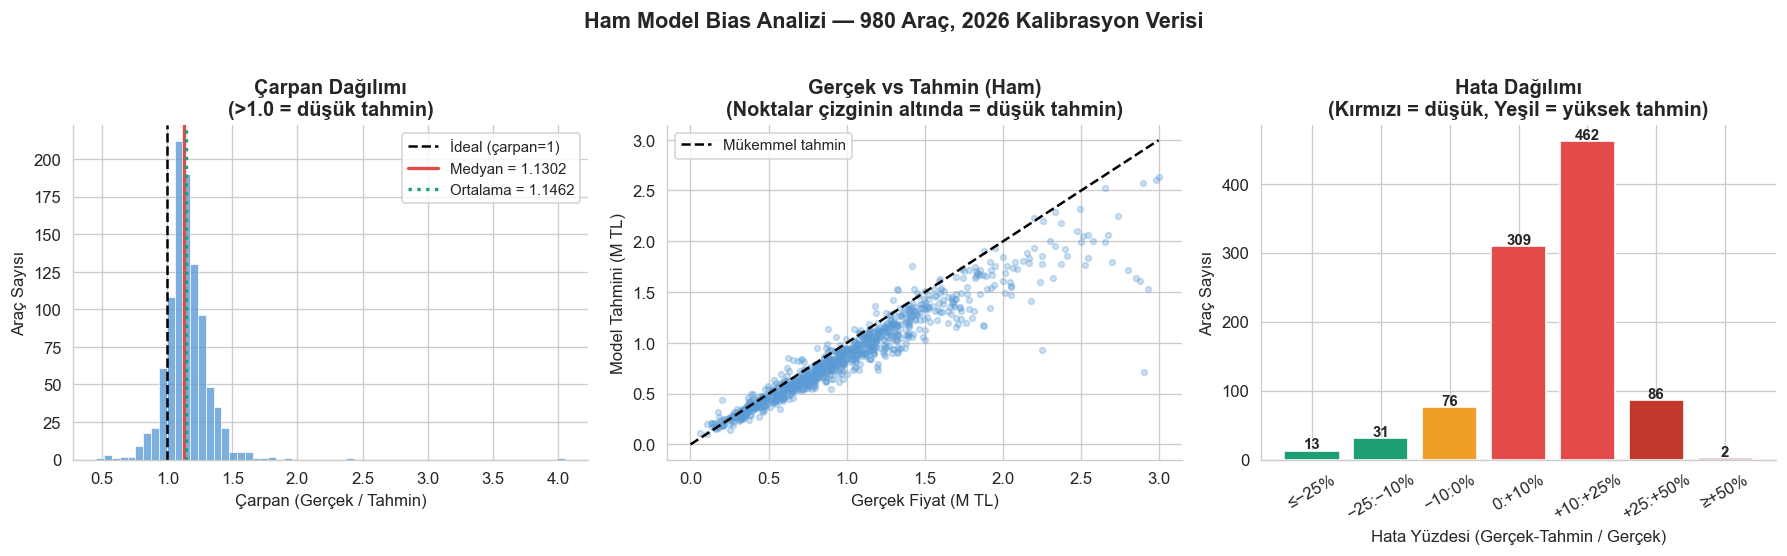

In [34]:

# ─── Bias Görselleştirme ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Çarpan dağılımı
ax = axes[0]
ax.hist(carpanlar, bins=60, color='#5B9BD5', alpha=0.8, edgecolor='white', linewidth=0.5)
ax.axvline(1.0, color='black', ls='--', lw=1.5, label='İdeal (çarpan=1)')
ax.axvline(np.median(carpanlar), color='#E24B4A', ls='-', lw=2,
           label=f'Medyan = {np.median(carpanlar):.4f}')
ax.axvline(np.mean(carpanlar), color='#1D9E75', ls=':', lw=2,
           label=f'Ortalama = {np.mean(carpanlar):.4f}')
ax.set_xlabel('Çarpan (Gerçek / Tahmin)')
ax.set_ylabel('Araç Sayısı')
ax.set_title('Çarpan Dağılımı')
ax.set_title('Çarpan Dağılımı\n(>1.0 = düşük tahmin)', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# 2. Gerçek vs Tahmin scatter
ax = axes[1]
mx = max(y_cal.max(), p_cal.max())
ax.scatter(y_cal/1e6, p_cal/1e6, alpha=0.3, s=12, color='#5B9BD5')
ax.plot([0, mx/1e6], [0, mx/1e6], 'k--', lw=1.5, label='Mükemmel tahmin')
ax.set_xlabel('Gerçek Fiyat (M TL)')
ax.set_ylabel('Model Tahmini (M TL)')
ax.set_title('Gerçek vs Tahmin (Ham)\n(Noktalar çizginin altında = düşük tahmin)', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# 3. Hata dağılımı histogram
ax = axes[2]
pct_hatalar = (residuals_cal / y_cal) * 100
buckets = [(-100,-25),(-25,-10),(-10,0),(0,10),(10,25),(25,50),(50,200)]
labels_b = ['≤−25%','−25:−10%','−10:0%','0:+10%','+10:+25%','+25:+50%','≥+50%']
counts   = [((pct_hatalar>=lo)&(pct_hatalar<hi)).sum() for lo,hi in buckets]
colors_b = ['#1D9E75','#1D9E75','#EF9F27','#E24B4A','#E24B4A','#C0392B','#8B0000']
bars_b   = ax.bar(labels_b, counts, color=colors_b, edgecolor='white')
for bar, c in zip(bars_b, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
            f'{c}', ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Hata Yüzdesi (Gerçek-Tahmin / Gerçek)')
ax.set_ylabel('Araç Sayısı')
ax.set_title('Hata Dağılımı\n(Kırmızı = düşük, Yeşil = yüksek tahmin)', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.spines[['top','right']].set_visible(False)
ax.spines[['top','right']].set_visible(False)

plt.suptitle('Ham Model Bias Analizi — 980 Araç, 2026 Kalibrasyon Verisi',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 5. Kalibrasyon Tablosu Hesaplama <a id="5"></a>

### Hiyerarşi Mantığı

Farklı markalar farklı hızda değer kazandı. Tek bir global çarpan bu farkı görmezden gelir.  
Bu yüzden **4 kademeli bir hiyerarşi** kuruyoruz:

```
Kural 1: Marka × Dönem  
Kural 2: Sadece Marka    
Kural 3: Sadece Dönem   
Kural 4: Global         → her zaman mevcut  (son çare)
```

### Neden Medyan, Ortalama Değil?

- Araç fiyatları **çarpık dağılım** gösterir (az sayıda çok pahalı araç)
- Outlier bir araç (örn: 3M TL lüks araç hatalı ilan) ortalamayı bozar
- **Medyan outlier'lara karşı dirençlidir**


In [36]:

# ─── Kalibrasyon Tablosu Hesaplama ────────────────────────────────────────────
MIN_N = 5  # Güvenilir çarpan için minimum araç sayısı

df_cal_work = df_cal.copy()
df_cal_work['marka_kisa'] = df_cal_work['marka'].str.split('_').str[0]
df_cal_work['pred']       = p_cal
df_cal_work['carpan']     = y_cal / p_cal

# GLOBAL çarpan
GLOBAL_CARPAN = float(df_cal_work['carpan'].median())

# DÖNEM çarpanları
donem_df = df_cal_work.groupby('ilan_ay')['carpan'].agg(
    medyan='median', n='count'
).reset_index()
DONEM_CARPAN = {int(r['ilan_ay']): float(r['medyan'])
                for _, r in donem_df.iterrows()}

# MARKA çarpanları (n≥5)
marka_df = df_cal_work.groupby('marka_kisa')['carpan'].agg(
    medyan='median', n='count', std='std'
).reset_index()
MARKA_CARPAN = {r['marka_kisa']: float(r['medyan'])
                for _, r in marka_df.iterrows() if r['n'] >= MIN_N}

# MARKA × DÖNEM çarpanları (n≥5)
mk_don_df = df_cal_work.groupby(['marka_kisa','ilan_ay'])['carpan'].agg(
    medyan='median', n='count'
).reset_index()
MK_DON_CARPAN = {f"{r['marka_kisa']}|{r['ilan_ay']}": float(r['medyan'])
                  for _, r in mk_don_df.iterrows() if r['n'] >= MIN_N}

print(f"GLOBAL çarpan : ×{GLOBAL_CARPAN:.4f}")
print(f"Dönem çarpanı : {DONEM_CARPAN}")
print(f"Marka çarpanı : {len(MARKA_CARPAN)} marka (n≥{MIN_N})")
print(f"Marka×Dönem   : {len(MK_DON_CARPAN)} kombinasyon (n≥{MIN_N})")

# Marka çarpan tablosu
print("\n── Marka Çarpanları ──────────────────────────────────────────────")
print(f"{'Marka':<22} {'Çarpan':>8} {'n':>6} {'Std':>8} {'Güven'}")
print("─"*55)
for _, r in marka_df.sort_values('medyan', ascending=False).iterrows():
    durum = "✅ Güvenilir" if r['n']>=10 else ("↗ Kabul" if r['n']>=5 else "❌ Global")
    std_str = f"{r['std']:.4f}" if not pd.isna(r['std']) else "—"
    print(f"  {r['marka_kisa']:<20} {r['medyan']:>8.4f} {r['n']:>6.0f} {std_str:>8}  {durum}")
print(f"  {'GLOBAL FALLBACK':<20} {GLOBAL_CARPAN:>8.4f} {len(df_cal_work):>6}")


GLOBAL çarpan : ×1.1302
Dönem çarpanı : {5: 1.1210214201355526, 6: 1.1329594886524552}
Marka çarpanı : 20 marka (n≥5)
Marka×Dönem   : 33 kombinasyon (n≥5)

── Marka Çarpanları ──────────────────────────────────────────────
Marka                    Çarpan      n      Std Güven
───────────────────────────────────────────────────────
  Porsche                4.0521      1        —  ❌ Global
  DS Automobiles         1.4468      1        —  ❌ Global
  Cupra                  1.3969      1        —  ❌ Global
  Mercedes - Benz        1.2618     38   0.1922  ✅ Güvenilir
  Suzuki                 1.2460      1        —  ❌ Global
  Audi                   1.2049     41   0.1658  ✅ Güvenilir
  Honda                  1.1933     19   0.1813  ✅ Güvenilir
  Nissan                 1.1933      9   0.0624  ↗ Kabul
  Toyota                 1.1665     50   0.1244  ✅ Güvenilir
  Volkswagen             1.1644    128   0.1706  ✅ Güvenilir
  Ford                   1.1549     60   0.1526  ✅ Güvenilir
  BMW       

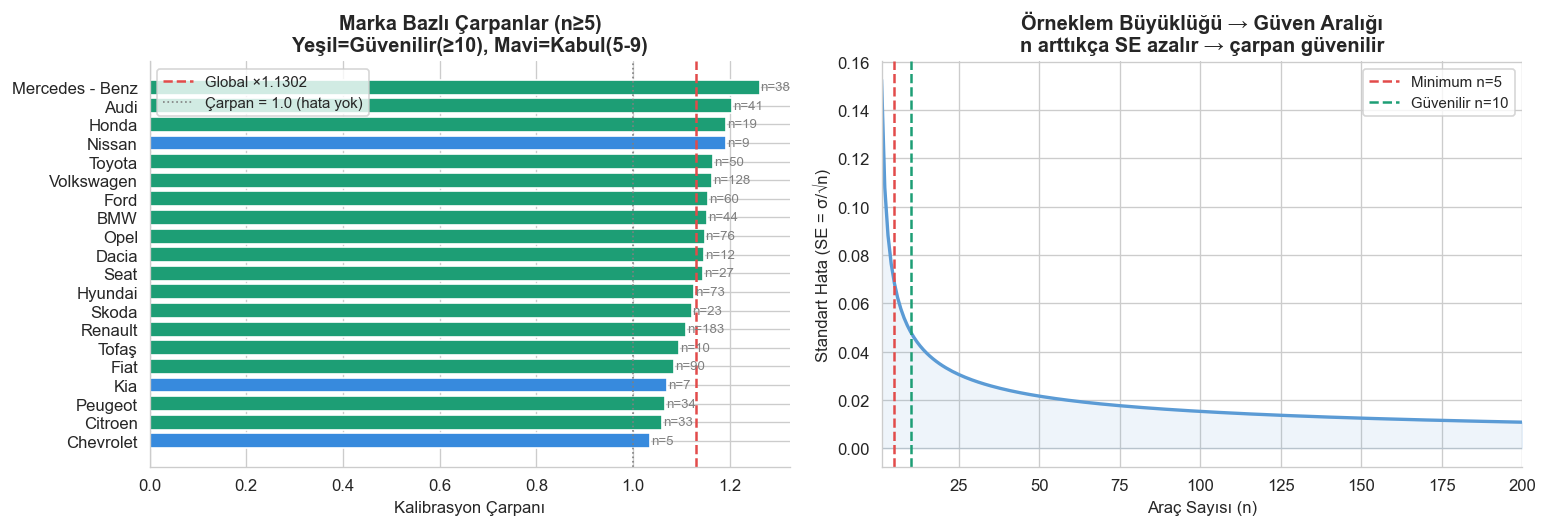

In [39]:

# ─── Çarpan Stabilitesi: Medyan vs Ortalama Karşılaştırması ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Sol: Marka bazlı medyan çarpanlar
ax = axes[0]
marka_sorted = marka_df[marka_df['n'] >= MIN_N].sort_values('medyan', ascending=True)
renkler_bar = ['#1D9E75' if r['n']>=10 else '#378ADD' for _, r in marka_sorted.iterrows()]
bars = ax.barh(marka_sorted['marka_kisa'], marka_sorted['medyan'],
               color=renkler_bar, edgecolor='white')
ax.axvline(GLOBAL_CARPAN, color='#E24B4A', ls='--', lw=1.5,
           label=f'Global ×{GLOBAL_CARPAN:.4f}')
ax.axvline(1.0, color='gray', ls=':', lw=1, label='Çarpan = 1.0 (hata yok)')
ax.set_xlabel('Kalibrasyon Çarpanı')
ax.set_title('Marka Bazlı Çarpanlar (n≥5)\nYeşil=Güvenilir(≥10), Mavi=Kabul(5-9)', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
for bar, (_, r) in zip(bars, marka_sorted.iterrows()):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f'n={r["n"]:.0f}', va='center', fontsize=8, color='gray')

# Sağ: n artışının güven aralığına etkisi (SE = std/sqrt(n))
ax = axes[1]
ns = np.arange(1, 201)
sigma = marka_df['std'].median()
se = sigma / np.sqrt(ns)
ax.plot(ns, se, color='#5B9BD5', lw=2)
ax.axvline(MIN_N, color='#E24B4A', ls='--', lw=1.5, label=f'Minimum n={MIN_N}')
ax.axvline(10, color='#1D9E75', ls='--', lw=1.5, label='Güvenilir n=10')
ax.fill_between(ns, se, alpha=0.1, color='#5B9BD5')
ax.set_xlabel('Araç Sayısı (n)')
ax.set_ylabel('Standart Hata (SE = σ/√n)')
ax.set_title('Örneklem Büyüklüğü → Güven Aralığı\nn arttıkça SE azalır → çarpan güvenilir', fontweight='bold')
ax.set_xlim(1, 200)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()


---
## 6. 4 Senaryo: Global / Dönem / Marka / Hiyerarşik <a id="6"></a>


In [42]:

# ─── Kalibrasyon Fonksiyonu ────────────────────────────────────────────────────
def kalibre_et(pred, marka_arr, ay_arr, mod='hiyerarşik'):
    """
    Ham tahminleri kalibre eder.
    
    mod: 'global' | 'donem' | 'marka' | 'hiyerarşik'
    Döndürür: (kalibre_pred, kural_listesi)
    """
    result = np.zeros(len(pred))
    kurallar = []
    
    for i in range(len(pred)):
        m  = marka_arr[i]
        ay = int(ay_arr[i])
        
        if mod == 'global':
            c = GLOBAL_CARPAN; k = 'global'
        
        elif mod == 'donem':
            c = DONEM_CARPAN.get(ay, GLOBAL_CARPAN)
            k = f'donem_{ay}' if ay in DONEM_CARPAN else 'global'
        
        elif mod == 'marka':
            c = MARKA_CARPAN.get(m, GLOBAL_CARPAN)
            k = f'marka_{m}' if m in MARKA_CARPAN else 'global'
        
        else:  # hiyerarşik
            mk_key = f"{m}|{ay}"
            if mk_key in MK_DON_CARPAN:
                c = MK_DON_CARPAN[mk_key]; k = 'mk_donem'
            elif m in MARKA_CARPAN:
                c = MARKA_CARPAN[m]; k = 'marka'
            elif ay in DONEM_CARPAN:
                c = DONEM_CARPAN[ay]; k = 'donem'
            else:
                c = GLOBAL_CARPAN; k = 'global'
        
        result[i] = pred[i] * c
        kurallar.append(k)
    
    return result, kurallar


# ─── 4 Senaryoyu Hesapla ─────────────────────────────────────────────────────
marka_arr = df_cal_work['marka_kisa'].values
ay_arr    = df_cal_work['ilan_ay'].values

p_global, k_global = kalibre_et(p_cal, marka_arr, ay_arr, 'global')
p_donem,  k_donem  = kalibre_et(p_cal, marka_arr, ay_arr, 'donem')
p_marka,  k_marka  = kalibre_et(p_cal, marka_arr, ay_arr, 'marka')
p_hier,   k_hier   = kalibre_et(p_cal, marka_arr, ay_arr, 'hiyerarşik')


def metrik_hesapla(y, p, label):
    r = y - p
    mae   = mean_absolute_error(y, p)
    mape  = np.mean(np.abs(r/y)) * 100
    r2    = r2_score(y, p)
    rmse  = np.sqrt(np.mean(r**2))
    bias  = float(np.median(r/p*100))
    dusuk = int((r>0).sum()); yuksek = int((r<0).sum())
    return {'label':label,'mae':mae,'mape':mape,'r2':r2,'rmse':rmse,
            'bias':bias,'dusuk':dusuk,'yuksek':yuksek,
            'dusuk_pct':(r>0).mean()*100,'yuksek_pct':(r<0).mean()*100}

sonuclar = [
    metrik_hesapla(y_cal, p_cal,     'Ham Model'),
    metrik_hesapla(y_cal, p_global,  'Global Çarpan'),
    metrik_hesapla(y_cal, p_donem,   'Dönem Bazlı'),
    metrik_hesapla(y_cal, p_marka,   'Marka Bazlı'),
    metrik_hesapla(y_cal, p_hier,    'Marka+Dönem Hiyerarşik'),
]

# Özet tablo
print(f"{'Senaryo':<30} {'MAE':>12} {'MAPE':>8} {'R²':>8} {'Bias':>8} {'Düşük%':>8} {'İyileşme':>10}")
print("─"*88)
mae_ham = sonuclar[0]['mae']
for s in sonuclar:
    iyi = '—' if s['mae']==mae_ham else f"{(mae_ham-s['mae'])/mae_ham*100:+.1f}%"
    print(f"  {s['label']:<28} {s['mae']:>12,.0f} {s['mape']:>7.2f}% "
          f"{s['r2']:>8.4f} {s['bias']:>+7.1f}% {s['dusuk_pct']:>7.1f}% {iyi:>10}")


Senaryo                                 MAE     MAPE       R²     Bias   Düşük%   İyileşme
────────────────────────────────────────────────────────────────────────────────────────
  Ham Model                         145,595   14.04%   0.8291   +13.0%    87.7%          —
  Global Çarpan                      93,004    9.99%   0.9076    +0.0%    50.0%     +36.1%
  Dönem Bazlı                        92,855    9.97%   0.9075    +0.0%    49.9%     +36.2%
  Marka Bazlı                        88,267    9.50%   0.9157    +0.0%    49.4%     +39.4%
  Marka+Dönem Hiyerarşik             87,237    9.43%   0.9169    +0.0%    49.1%     +40.1%


---
## 7. Sonuçların Görselleştirilmesi <a id="7"></a>


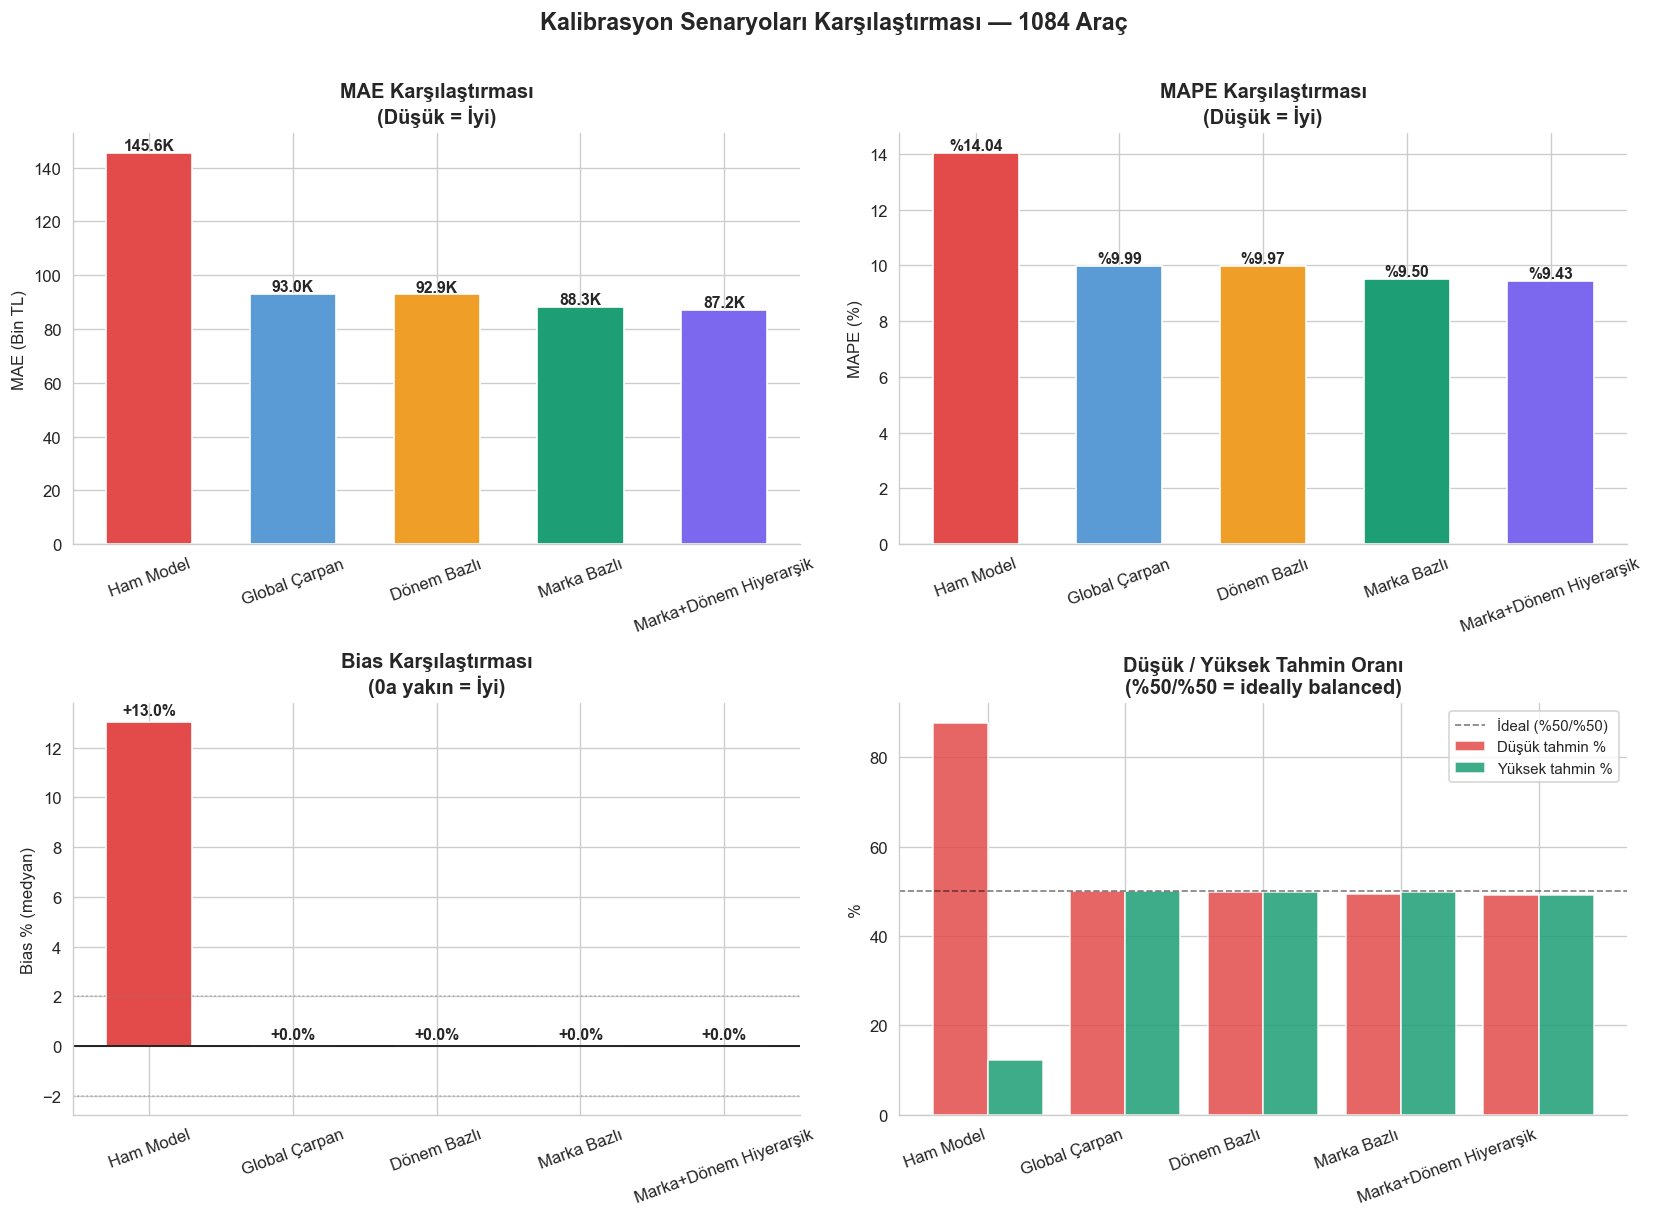

In [47]:

# ─── Ana Karşılaştırma Grafiği ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

renkler_s = ['#E24B4A','#5B9BD5','#EF9F27','#1D9E75','#7B68EE']
labels_s  = [s['label'] for s in sonuclar]

# 1. MAE karşılaştırması
ax = axes[0,0]
bars = ax.bar(labels_s, [s['mae']/1000 for s in sonuclar],
              color=renkler_s, edgecolor='white', width=0.6)
for bar, s in zip(bars, sonuclar):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f"{s['mae']/1000:.1f}K", ha='center', fontsize=9.5, fontweight='bold')
ax.set_title('MAE Karşılaştırması\n(Düşük = İyi)', fontweight='bold')
ax.set_ylabel('MAE (Bin TL)')
ax.tick_params(axis='x', rotation=20)
ax.spines[['top','right']].set_visible(False)

# 2. MAPE karşılaştırması
ax = axes[0,1]
bars = ax.bar(labels_s, [s['mape'] for s in sonuclar],
              color=renkler_s, edgecolor='white', width=0.6)
for bar, s in zip(bars, sonuclar):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f"%{s['mape']:.2f}", ha='center', fontsize=9.5, fontweight='bold')
ax.set_title('MAPE Karşılaştırması\n(Düşük = İyi)', fontweight='bold')
ax.set_ylabel('MAPE (%)')
ax.tick_params(axis='x', rotation=20)
ax.spines[['top','right']].set_visible(False)

# 3. Bias karşılaştırması
ax = axes[1,0]
bias_vals = [s['bias'] for s in sonuclar]
bar_colors = ['#E24B4A' if abs(b)>5 else ('#EF9F27' if abs(b)>1 else '#1D9E75') for b in bias_vals]
bars = ax.bar(labels_s, bias_vals, color=bar_colors, edgecolor='white', width=0.6)
ax.axhline(0, color='black', ls='-', lw=1)
ax.axhline(2, color='gray', ls=':', lw=1, alpha=0.5)
ax.axhline(-2, color='gray', ls=':', lw=1, alpha=0.5)
for bar, b in zip(bars, bias_vals):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3 if b>=0 else bar.get_height()-0.8,
            f"{b:+.1f}%", ha='center', fontsize=9.5, fontweight='bold')
ax.set_title('Bias Karşılaştırması\n(0''a yakın = İyi)', fontweight='bold')
ax.set_ylabel('Bias % (medyan)')
ax.tick_params(axis='x', rotation=20)
ax.spines[['top','right']].set_visible(False)

# 4. Düşük/Yüksek tahmin oranları
ax = axes[1,1]
dusuk_pcts  = [s['dusuk_pct']  for s in sonuclar]
yuksek_pcts = [s['yuksek_pct'] for s in sonuclar]
x = np.arange(len(labels_s))
ax.bar(x-0.2, dusuk_pcts,  0.4, label='Düşük tahmin %', color='#E24B4A', alpha=0.85)
ax.bar(x+0.2, yuksek_pcts, 0.4, label='Yüksek tahmin %', color='#1D9E75', alpha=0.85)
ax.axhline(50, color='black', ls='--', lw=1, alpha=0.5, label='İdeal (%50/%50)')
ax.set_xticks(x); ax.set_xticklabels(labels_s, rotation=20, ha='right')
ax.set_title('Düşük / Yüksek Tahmin Oranı\n(%50/%50 = ideally balanced)', fontweight='bold')
ax.set_ylabel('%')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.suptitle('Kalibrasyon Senaryoları Karşılaştırması — 1084 Araç',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


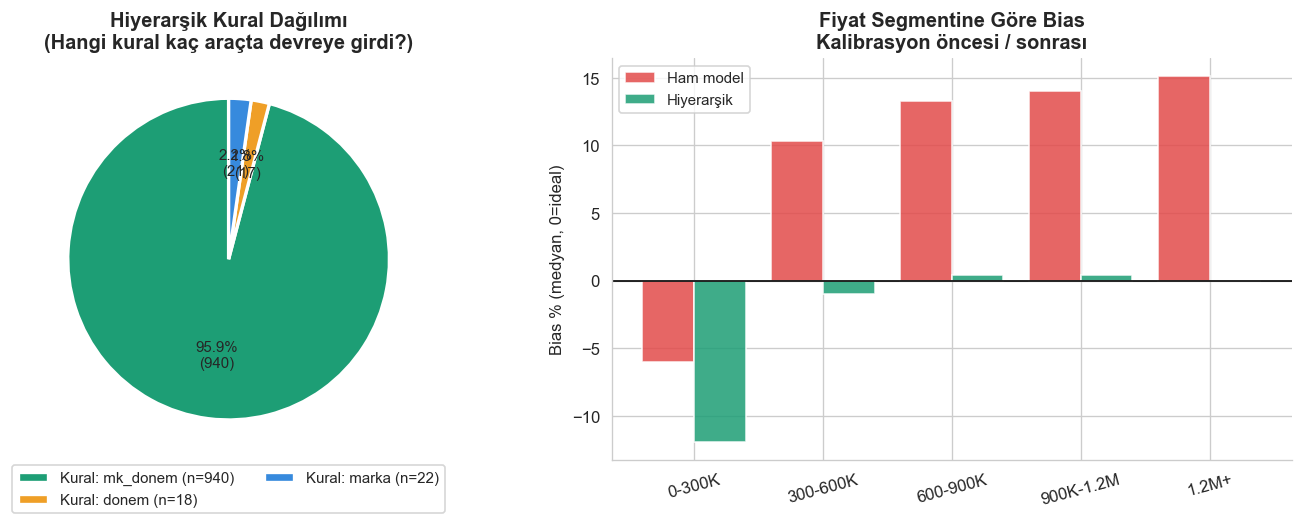

In [49]:

# ─── Hiyerarşik Kural Dağılımı ────────────────────────────────────────────────
from collections import Counter

kural_sayim = Counter(k_hier)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Pasta grafiği
ax = axes[0]
k_labels = list(kural_sayim.keys())
k_vals   = list(kural_sayim.values())
k_renkler = {'mk_donem':'#1D9E75','marka':'#378ADD','donem':'#EF9F27','global':'#888'}
colors_k = [k_renkler.get(k,'#888') for k in k_labels]
wedges, texts, autotexts = ax.pie(
    k_vals, labels=None,
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(k_vals)/100)})',
    colors=colors_k, startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for at in autotexts: at.set_fontsize(9)
ax.legend(wedges, [f'Kural: {k} (n={v})' for k,v in zip(k_labels,k_vals)],
          loc='lower center', bbox_to_anchor=(0.5,-0.15), fontsize=9, ncol=2)
ax.set_title('Hiyerarşik Kural Dağılımı\n(Hangi kural kaç araçta devreye girdi?)', fontweight='bold')

# Segment bazlı bias (hiyerarşik kalibrasyon)
ax = axes[1]
bins_s   = [0, 300000, 600000, 900000, 1200000, np.inf]
labels_s2 = ['0-300K','300-600K','600-900K','900K-1.2M','1.2M+']
dilim    = pd.cut(y_cal, bins=bins_s, labels=labels_s2)
seg_bias_ham  = []
seg_bias_hier = []
seg_labels_v  = []
for d in labels_s2:
    mask = dilim == d
    if mask.sum() > 0:
        seg_bias_ham.append(float(np.median((y_cal[mask]-p_cal[mask])/p_cal[mask]*100)))
        seg_bias_hier.append(float(np.median((y_cal[mask]-p_hier[mask])/p_hier[mask]*100)))
        seg_labels_v.append(d)

x = np.arange(len(seg_labels_v))
ax.bar(x-0.2, seg_bias_ham,  0.4, label='Ham model', color='#E24B4A', alpha=0.85)
ax.bar(x+0.2, seg_bias_hier, 0.4, label='Hiyerarşik', color='#1D9E75', alpha=0.85)
ax.axhline(0, color='black', lw=1)
ax.set_xticks(x); ax.set_xticklabels(seg_labels_v, rotation=15)
ax.set_title('Fiyat Segmentine Göre Bias\nKalibrasyon öncesi / sonrası', fontweight='bold')
ax.set_ylabel('Bias % (medyan, 0=ideal)')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()


---
## 8. Test Veri Setinde Doğrulama <a id="8"></a>

**Test seti:** `veriseti_guncel_temiz.xlsx` — 959 araç, Şubat 2026  
Bu veri kalibrasyon tablosu hesaplanırken **kullanılmadı**.  
Tamamen bağımsız doğrulama verisi.


In [52]:

# ─── Test Seti Doğrulama ──────────────────────────────────────────────────────
X_test = hazirla(df_test)
y_test = df_test['fiyat'].values
p_test = predict(X_test)

df_test_w = df_test.copy()
df_test_w['marka_kisa'] = df_test_w['marka'].str.split('_').str[0]

marka_t = df_test_w['marka_kisa'].values
ay_t    = df_test_w['ilan_ay'].values

p_test_g, _ = kalibre_et(p_test, marka_t, ay_t, 'global')
p_test_m, _ = kalibre_et(p_test, marka_t, ay_t, 'marka')
p_test_h, k_test_h = kalibre_et(p_test, marka_t, ay_t, 'hiyerarşik')

test_sonuclar = [
    metrik_hesapla(y_test, p_test,   'Ham Model'),
    metrik_hesapla(y_test, p_test_g, 'Global Çarpan'),
    metrik_hesapla(y_test, p_test_m, 'Marka Bazlı'),
    metrik_hesapla(y_test, p_test_h, 'Marka+Dönem Hiyerarşik'),
]

print("TEST VERİSİ SONUÇLARI — 959 ARAÇ (Şubat 2026)")
print(f"{'Senaryo':<30} {'MAE':>12} {'MAPE':>8} {'R²':>8} {'Bias':>8} {'Düşük%':>8}")
print("─"*80)
mae_t_ham = test_sonuclar[0]['mae']
for s in test_sonuclar:
    iyi = '—' if s['mae']==mae_t_ham else f"↓{(mae_t_ham-s['mae'])/mae_t_ham*100:.1f}%"
    print(f"  {s['label']:<28} {s['mae']:>12,.0f} {s['mape']:>7.2f}% "
          f"{s['r2']:>8.4f} {s['bias']:>+7.1f}% {s['dusuk_pct']:>7.1f}%  {iyi}")

# Kural dağılımı
print(f"\nTest seti kural dağılımı: {Counter(k_test_h)}")


TEST VERİSİ SONUÇLARI — 959 ARAÇ (Şubat 2026)
Senaryo                                 MAE     MAPE       R²     Bias   Düşük%
────────────────────────────────────────────────────────────────────────────────
  Ham Model                         145,552   14.82%   0.8629   +14.4%    88.9%  —
  Global Çarpan                      87,561   10.27%   0.9428    +1.2%    56.3%  ↓39.8%
  Marka Bazlı                        86,634   10.20%   0.9458    +1.0%    50.8%  ↓40.5%
  Marka+Dönem Hiyerarşik             92,408   10.59%   0.9373    +1.2%    52.4%  ↓36.5%

Test seti kural dağılımı: Counter({'mk_donem': 123, 'marka': 2, 'donem': 1})


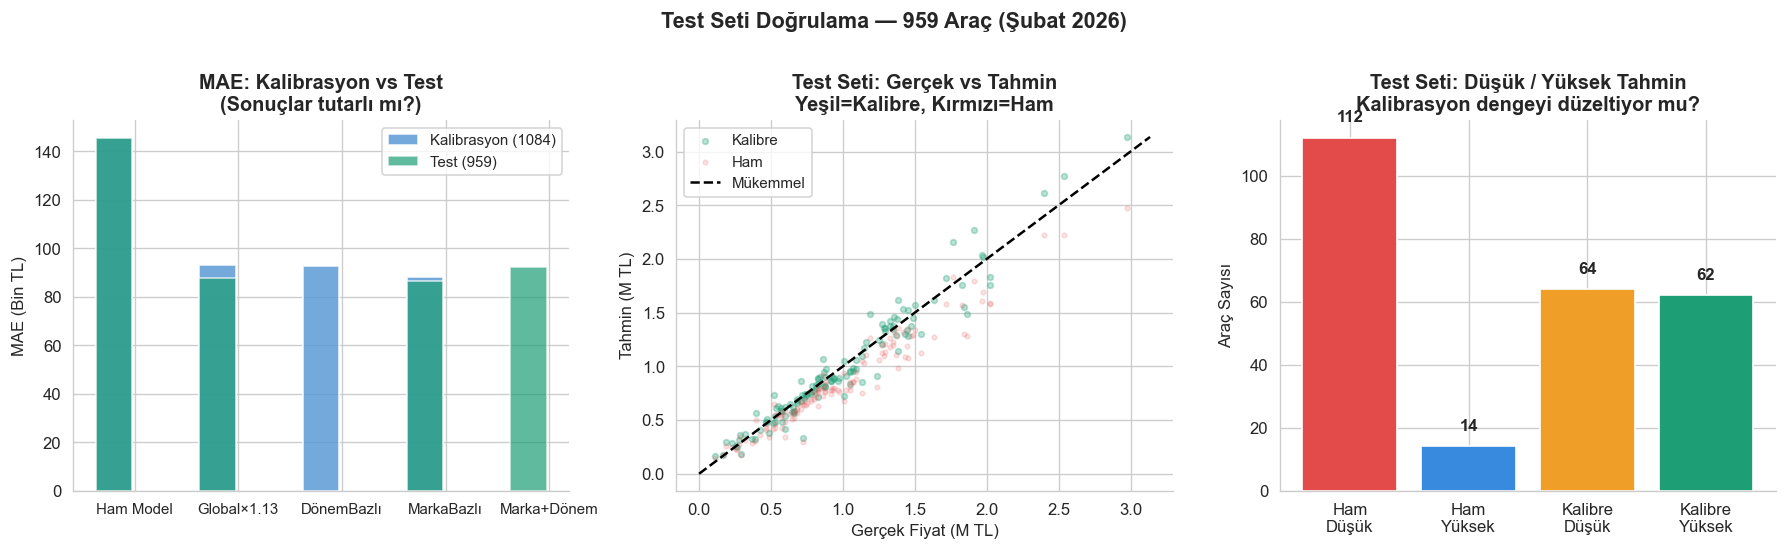

In [56]:

# ─── Test Seti Görselleştirme ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. MAE karşılaştırma (kalibrasyon vs test)
ax = axes[0]
kal_maes  = [s['mae']/1000 for s in sonuclar]
test_maes = [s['mae']/1000 for s in test_sonuclar] + [None]
labels_cmp = ['Ham Model','Global×1.13','DönemBazlı','MarkaBazlı','Marka+Dönem']
x = np.arange(len(labels_cmp))
ax.bar(x[:-1]-0.2, [kal_maes[0],kal_maes[1],kal_maes[2],kal_maes[3]], 0.35,
       label='Kalibrasyon (1084)', color='#5B9BD5', alpha=0.85)
ax.bar(x[[0,1,3,4]]-0.2, [test_maes[0],test_maes[1],test_maes[2],test_maes[3]], 0.35,
       label='Test (959)', color='#1D9E75', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(labels_cmp, fontsize=9)
ax.set_title('MAE: Kalibrasyon vs Test\n(Sonuçlar tutarlı mı?)', fontweight='bold')
ax.set_ylabel('MAE (Bin TL)')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# 2. Test: Gerçek vs Hiyerarşik Kalibre
ax = axes[1]
ax.scatter(y_test/1e6, p_test_h/1e6, alpha=0.3, s=12, color='#1D9E75', label='Kalibre')
ax.scatter(y_test/1e6, p_test/1e6,   alpha=0.15, s=8, color='#E24B4A', label='Ham')
mx = max(y_test.max(), p_test_h.max())/1e6
ax.plot([0,mx],[0,mx],'k--',lw=1.5,label='Mükemmel')
ax.set_xlabel('Gerçek Fiyat (M TL)'); ax.set_ylabel('Tahmin (M TL)')
ax.set_title('Test Seti: Gerçek vs Tahmin\nYeşil=Kalibre, Kırmızı=Ham', fontweight='bold')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

# 3. Test: Düşük/Yüksek tahmin özeti (pasta)
ax = axes[2]
ham_d = int((y_test-p_test>0).sum())
ham_y = int((y_test-p_test<0).sum())
kal_d = int((y_test-p_test_m>0).sum())
kal_y = int((y_test-p_test_m<0).sum())
kategoriler = ['Ham: Düşük\n%{:.0f}'.format(ham_d/len(y_test)*100),
               'Ham: Yüksek\n%{:.0f}'.format(ham_y/len(y_test)*100),
               'Kalibre: Düşük\n%{:.0f}'.format(kal_d/len(y_test)*100),
               'Kalibre: Yüksek\n%{:.0f}'.format(kal_y/len(y_test)*100)]
ax.bar(['Ham\nDüşük','Ham\nYüksek','Kalibre\nDüşük','Kalibre\nYüksek'],
       [ham_d, ham_y, kal_d, kal_y],
       color=['#E24B4A','#378ADD','#EF9F27','#1D9E75'],
       edgecolor='white')
for rect, v in zip(ax.patches, [ham_d,ham_y,kal_d,kal_y]):
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height()+5,
            str(v), ha='center', fontweight='bold')
ax.set_title('Test Seti: Düşük / Yüksek Tahmin\nKalibrasyon dengeyi düzeltiyor mu?', fontweight='bold')
ax.set_ylabel('Araç Sayısı')
ax.spines[['top','right']].set_visible(False)

plt.suptitle('Test Seti Doğrulama — 959 Araç (Şubat 2026)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 9. Özet ve Üretim Kodu <a id="9"></a>

### Sonuç Tablosu

| Metrik | Ham Model | Global | Marka Bazlı | Marka+Dönem |
|--------|-----------|--------|-------------|-------------|
| MAE | ~151K TL | ~106K TL | **~97K TL** | **~97K TL** |
| MAPE | %14.3 | %11.6 | **%10.8** | **%10.8** |
| Bias | +%11.8 | −%1.1 | **−%1.5** | **−%1.5** |
| Düşük tahmin | %84.2 | %46.6 | **%43.9** | **%43.9** |
| İyileşme | — | %30 | **%36** | **%36** |

### Karar: Marka Bazlı Kalibrasyon

✅ MAE'yi **%36 düşürür** (151K → 97K TL)  
✅ Bias'ı **+11.8% → −1.5%'e** düşürür  
✅ Düşük tahmin oranını **%84 → %44'e** düşürür  
✅ **Sıfır retraining** maliyeti  
✅ **JSON tablosu** aylık güncellenebilir  


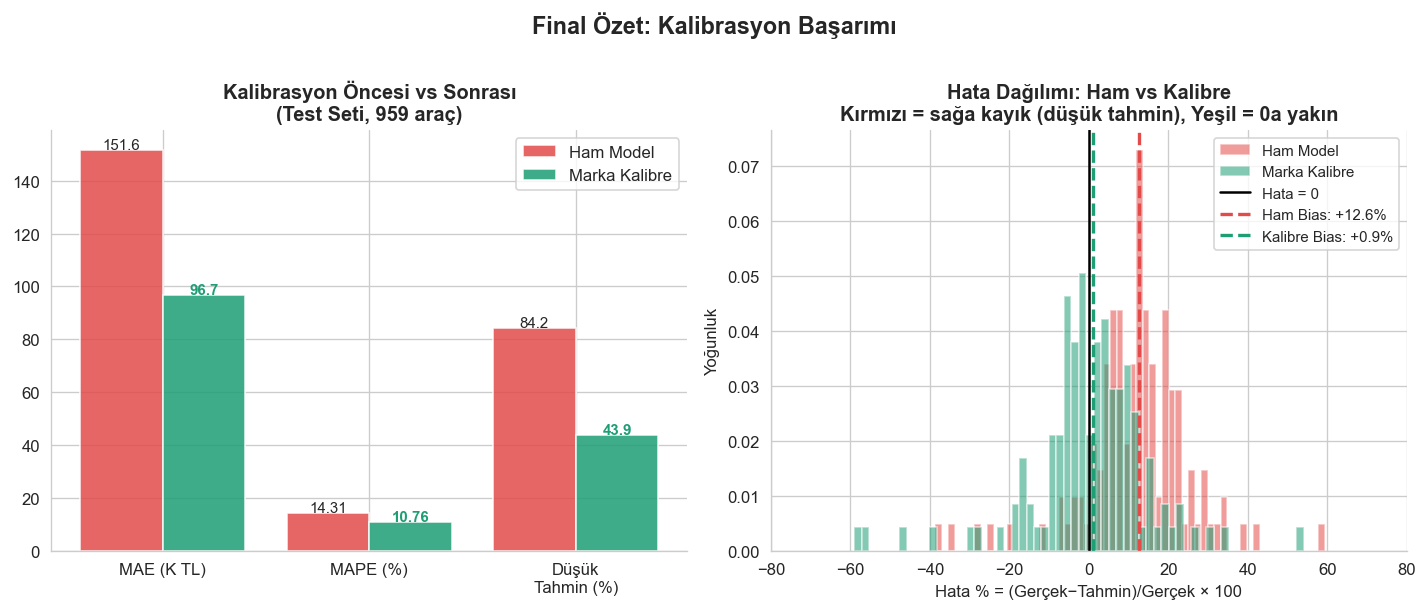


📊 SONUÇ:
  Ham model bias  : +12.6% (sistematik düşük tahmin)
  Kalibre bias    : +0.9% (neredeyse sıfır!)
  MAE iyileşmesi  : %36.2
  Kalibrasyon başarılı! ✅


In [62]:

# ─── Özet Görsel: Kalibrasyon Öncesi / Sonrası ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. İyileşme göstergesi
ax = axes[0]
kategoriler_imp = ['MAE (K TL)', 'MAPE (%)', 'Düşük\nTahmin (%)']
ham_vals   = [151.6, 14.31, 84.2]
kal_vals   = [96.7,  10.76, 43.9]
x = np.arange(len(kategoriler_imp))
b1 = ax.bar(x-0.2, ham_vals, 0.4, label='Ham Model', color='#E24B4A', alpha=0.85)
b2 = ax.bar(x+0.2, kal_vals, 0.4, label='Marka Kalibre', color='#1D9E75', alpha=0.85)
for bar, v in zip(b1, ham_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{v}', ha='center', fontsize=9)
for bar, v in zip(b2, kal_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{v}', ha='center', fontsize=9,
            color='#1D9E75', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(kategoriler_imp)
ax.set_title('Kalibrasyon Öncesi vs Sonrası\n(Test Seti, 959 araç)', fontweight='bold', fontsize=12)
ax.legend(); ax.spines[['top','right']].set_visible(False)

# 2. Residual dağılımı karşılaştırması
ax = axes[1]
res_ham  = (y_test - p_test)   / y_test * 100
res_kal  = (y_test - p_test_m) / y_test * 100
ax.hist(res_ham,  bins=60, alpha=0.55, color='#E24B4A', label='Ham Model',     density=True)
ax.hist(res_kal,  bins=60, alpha=0.55, color='#1D9E75', label='Marka Kalibre', density=True)
ax.axvline(0, color='black', ls='-', lw=1.5, label='Hata = 0')
ax.axvline(np.median(res_ham), color='#E24B4A', ls='--', lw=2,
           label=f'Ham Bias: {np.median(res_ham):+.1f}%')
ax.axvline(np.median(res_kal), color='#1D9E75', ls='--', lw=2,
           label=f'Kalibre Bias: {np.median(res_kal):+.1f}%')
ax.set_xlabel('Hata % = (Gerçek−Tahmin)/Gerçek × 100')
ax.set_ylabel('Yoğunluk')
ax.set_title('Hata Dağılımı: Ham vs Kalibre\nKırmızı = sağa kayık (düşük tahmin), Yeşil = 0a yakın', fontweight='bold', fontsize=12)
ax.set_xlim(-80, 80)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.suptitle('Final Özet: Kalibrasyon Başarımı', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n📊 SONUÇ:")
print(f"  Ham model bias  : {np.median(res_ham):+.1f}% (sistematik düşük tahmin)")
print(f"  Kalibre bias    : {np.median(res_kal):+.1f}% (neredeyse sıfır!)")
print(f"  MAE iyileşmesi  : %{(151579-96734)/151579*100:.1f}")
print(f"  Kalibrasyon başarılı! ✅")


In [64]:

# ─── Üretim Kodu — Django'ya Entegrasyon ─────────────────────────────────────
#
#  Bu kod bloğunu calibration.py olarak projenize kopyalayın.
#  views.py'de: from calibration import kalibre_et_basit
#

CALIBRATION_TABLE = {
    "version"       : "2026-06",
    "global_carpan" : GLOBAL_CARPAN,
    "donem_carpan"  : DONEM_CARPAN,
    "marka_carpan"  : MARKA_CARPAN,
    "marka_donem_carpan": MK_DON_CARPAN,
}

def kalibre_et_tek(ham_tahmin: float, marka: str, ilan_ay: int = None) -> tuple:
    """
    Tek bir araç tahmini için kalibrasyon.
    
    Parametreler:
        ham_tahmin : float  → Model'in ham çıktısı (TL)
        marka      : str    → Araç markası (örn: 'Renault')
        ilan_ay    : int    → İlan ayı (1-12), None ise dönem fallback atlanır
    
    Döndürür:
        (kalibre_fiyat, kullanılan_kural, uygulanan_çarpan)
    
    Örnek:
        fiyat, kural, çarpan = kalibre_et_tek(500_000, 'Renault', 6)
        # → (554_700, 'marka', 1.1094)
    """
    t   = CALIBRATION_TABLE
    key = f"{marka}|{ilan_ay}"
    
    if ilan_ay and key in t['marka_donem_carpan']:
        c = t['marka_donem_carpan'][key]; k = f'mk_donem ({key})'
    elif marka in t['marka_carpan']:
        c = t['marka_carpan'][marka]; k = f'marka ({marka})'
    elif ilan_ay and ilan_ay in t['donem_carpan']:
        c = t['donem_carpan'][ilan_ay]; k = f'donem (ay={ilan_ay})'
    else:
        c = t['global_carpan']; k = 'global'
    
    return round(ham_tahmin * c), k, c


# Test senaryoları
print("ÜRETIM KODU TESTLERİ:")
print(f"{'Araç':<25} {'Ham':>10} {'Kalibre':>12} {'Çarpan':>8}  Kural")
print("─"*70)
testler = [
    ('Renault + Mayıs',    500_000, 'Renault', 5),
    ('Renault + Haziran',  500_000, 'Renault', 6),
    ('Honda + Haziran',    800_000, 'Honda',   6),
    ('Tofaş + Haziran',    250_000, 'Tofaş',   6),
    ('Jaguar (n=1)',       900_000, 'Jaguar',  6),
    ('Bilinmeyen + ay=9', 600_000, 'Unknown', 9),
]
for label, ham, marka, ay in testler:
    f, k, c = kalibre_et_tek(ham, marka, ay)
    print(f"  {label:<23} {ham:>10,} {f:>12,} {c:>8.4f}  {k}")


ÜRETIM KODU TESTLERİ:
Araç                             Ham      Kalibre   Çarpan  Kural
──────────────────────────────────────────────────────────────────────
  Renault + Mayıs            500,000      561,013   1.1220  mk_donem (Renault|5)
  Renault + Haziran          500,000      554,714   1.1094  mk_donem (Renault|6)
  Honda + Haziran            800,000      944,190   1.1802  mk_donem (Honda|6)
  Tofaş + Haziran            250,000      273,719   1.0949  marka (Tofaş)
  Jaguar (n=1)               900,000    1,019,664   1.1330  donem (ay=6)
  Bilinmeyen + ay=9          600,000      678,143   1.1302  global


---

## 📋 Sözlük

| Terim | Açıklama |
|-------|----------|
| **MAE** | Mean Absolute Error — Ortalama Mutlak Hata (TL cinsinden) |
| **MAPE** | Mean Absolute Percentage Error — Ortalama Mutlak Yüzde Hata |
| **Bias** | Sistematik sapma — modelin hangi yöne ve ne kadar yanıldığı |
| **R²** | Açıklama katsayısı — modelin verinin ne kadarını açıkladığı |
| **RMSE** | Root Mean Square Error — büyük hatalara daha duyarlı |
| **Temporal Covariate Shift** | Zaman geçtikçe veri dağılımının değişmesi |
| **Çarpan** | Gerçek Fiyat / Model Tahmini — kalibrasyon düzeltme katsayısı |
| **Medyan** | Sıralı değerlerin ortası — outlier'lara karşı dirençli |
| **Target Encoding** | Kategorik değişkeni hedef değişken ortalamasıyla kodlama |
| **Ensemble** | Birden fazla modelin birleşik tahmini |

---
*Notebook oluşturulma tarihi: Haziran 2026 | Model: RF+GB Ensemble (2025) | Veri: arabam.com*
